# Ecommerce Conversion Funnel Analysis and Optimization

## Introduction

### Background
Understanding how users move through an e-commerce platform is critical for improving conversion rates and maximizing revenue. While large volumes of user activity are generated, not all interactions lead to purchases. Identifying where users drop off in the conversion journey is a key analytical challenge.

### Problem Statement
Users interact with products through viewing, adding to cart, and purchasing, but a large portion of these interactions do not result in completed transactions. Without identifying where and why users drop off, it becomes difficult to optimize the conversion funnel and improve overall performance.

### Analytical Objectives
The analysis is designed to address the following key questions:

- What are the conversion rates at each stage of the funnel (view → cart → purchase)?  
- At which stage does the most significant user drop-off occur?  
- How does user behavior differ at the **session level**, and what patterns lead to successful conversions?  
- How do conversion rates vary across **product categories and brands**?  
- How does **price influence** user progression through the funnel?  
- What behavioral patterns distinguish converting sessions from non-converting ones?  
- What actionable insights can be derived to improve overall conversion performance?  

### Dataset Context
The analysis is based on a large-scale behavioral dataset collected from a **large multi-category online store**, containing approximately **67 million user interaction events** for **December 2019**.

Each row in the dataset represents an individual user–product interaction event, forming a many-to-many relationship between users and products. The data captures detailed user activity across the platform, including product views, cart additions, and purchases, along with associated timestamps, pricing, and session identifiers.

The dataset is part of a broader collection spanning **October 2019 to April 2020**, and was collected through the **Open CDP project**, with data provided by the REES46 marketing platform.

### Data Source
The dataset used in this analysis is sourced from:

- Kaggle: https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store  
- REES46 (original data provider): https://rees46.com/

These sources provide detailed logs of user interactions on an e-commerce platform, including product views, cart additions, and purchases.

### Data Preparation
Due to the large size of the dataset (approximately 67 million events for a single month), direct analysis using raw CSV files would be inefficient and memory-intensive. To address this, a preprocessing workflow was implemented prior to analysis.

The raw compressed data was processed in chunks to ensure memory efficiency and avoid system limitations. During this stage, structural consistency was validated and data types were standardized. The dataset was then converted into an optimized **Parquet format**, significantly improving read performance and enabling faster analytical operations.

This approach ensures that the analysis is both **scalable and efficient**, aligning with practical data workflows used when handling large-scale event data in real-world environments.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df = pd.read_parquet("../data/processed/2019-Dec.parquet")

## Dataset Shape

In [3]:
df.shape

(67430759, 9)

## Data Preview

In [4]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00+00:00,view,1005105,2232732093077520756,construction.tools.light,apple,1302.48,556695836,ca5eefc5-11f9-450c-91ed-380285a0bc80
1,2019-12-01 00:00:00+00:00,view,22700068,2232732091643068746,None,force,102.96,577702456,de33debe-c7bf-44e8-8a12-3bf8421f842a
2,2019-12-01 00:00:01+00:00,view,2402273,2232732100769874463,appliances.personal.massager,bosch,313.52,539453785,5ee185a7-0689-4a33-923d-ba0130929a76
3,2019-12-01 00:00:02+00:00,purchase,26400248,2053013553056579841,computers.peripherals.printer,None,132.31,535135317,61792a26-672f-4e61-9832-7b63bb1714db
4,2019-12-01 00:00:02+00:00,view,20100164,2232732110089618156,apparel.trousers,nika,101.68,517987650,906c6ca8-ff5c-419a-bde9-967ba8e2233e


## Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67430759 entries, 0 to 67430758
Data columns (total 9 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[us, UTC]
 1   event_type     object             
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  object             
 5   brand          object             
 6   price          float64            
 7   user_id        int64              
 8   user_session   object             
dtypes: datetime64[us, UTC](1), float64(1), int64(3), object(4)
memory usage: 4.5+ GB


**Observations:**
- The dataset contains ~67 million records with correctly structured features for user interactions.
- Key fields such as timestamps, event types, and user/session identifiers are properly formatted for analysis.

## Missing Values Check

In [6]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

brand            8113492
category_code    7078121
user_session          21
dtype: int64

Missing values are primarily concentrated in the `brand` and `category_code` columns, which are optional descriptive attributes and may not be available for all products. A small number of records have missing `user_session` values, which will need to be removed as session identifiers are essential for funnel analysis.

## Duplicate Records Check

In [7]:
df.duplicated().sum()

0

No duplicate records are present in the dataset, indicating that each event represents a unique user–product interaction.

## Event Type Distribution

In [8]:
df['event_type'].value_counts()

event_type
view        62984129
cart         3284602
purchase     1162028
Name: count, dtype: int64

The distribution of event types shows that the majority of interactions are product views, with significantly fewer cart additions and purchases. This indicates a substantial drop-off as users progress through the funnel, highlighting the need to analyze conversion rates and identify friction points in the user journey.

## Time Range Validation

In [9]:
df['event_time'].min(), df['event_time'].max()

(Timestamp('2019-12-01 00:00:00+0000', tz='UTC'),
 Timestamp('2019-12-31 23:59:59+0000', tz='UTC'))

The dataset covers user activity events from December 1 to December 31, 2019.

## Handling Missing Values: user_session

In [10]:
df = df.dropna(subset=['user_session'])

## Handling Missing Values: brand and category_code

In [11]:
df['brand_clean'] = df['brand'].fillna('unknown')
df['category_code_clean'] = df['category_code'].fillna('unknown')

Records with missing `user_session` values are removed, as session identifiers are essential for constructing the conversion funnel and tracking user journeys. Without a valid session, these events cannot be meaningfully grouped or analyzed.
In contrast, missing values in `brand` and `category_code` are retained and replaced with `'unknown'`, as these fields represent optional product attributes. Treating them as a separate category preserves the data while allowing consistent grouping and analysis.

## Validation of Missing Value Handling

In [12]:
df[['user_session', 'brand_clean', 'category_code_clean']].isnull().sum()

user_session           0
brand_clean            0
category_code_clean    0
dtype: int64

# Session-Level Funnel Analysis

To analyze user progression through the funnel, event-level data is aggregated at the session level. Each session is evaluated based on whether it includes view, cart, and purchase events.

### Session-Level Aggregation

In [13]:
session_funnel = df.groupby("user_session")["event_type"].value_counts().unstack(fill_value=0)

In [14]:
df['user_session'].nunique()

15581360

## Session-Level Aggregated Data Preview

In [15]:
session_funnel.head()

event_type,cart,purchase,view
user_session,,,
0000013c-0ccc-4b8a-a4f7-06ec6b4ce13a,0,0,1
00000348-8463-4832-9556-18191384baa0,0,0,1
00000361-1394-4fe6-a29b-4bed6c17193a,1,1,1
000004f0-7a1c-4bae-a9d0-c1978b28cb52,0,0,1
0000052a-e634-4d0c-a798-42d46d1101f3,0,0,1


## Session-Level Funnel Construction

In [16]:
session_funnel_binary = session_funnel.copy()

session_funnel_binary["view"] = (session_funnel_binary["view"] > 0).astype(int)
session_funnel_binary["cart"] = (session_funnel_binary["cart"] > 0).astype(int)
session_funnel_binary["purchase"] = (session_funnel_binary["purchase"] > 0).astype(int)

## Session-Level Funnel Metrics

In [17]:
total_sessions = session_funnel_binary.shape[0]

view_sessions = session_funnel_binary["view"].sum()
cart_sessions = session_funnel_binary["cart"].sum()
purchase_sessions = session_funnel_binary["purchase"].sum()

view_to_cart_rate = cart_sessions / view_sessions
cart_to_purchase_rate = purchase_sessions / cart_sessions
view_to_purchase_rate = purchase_sessions / view_sessions

## Session-Level Funnel Metrics Output

In [18]:
print("Total sessions:", total_sessions)
print("View sessions:", view_sessions)
print("Cart sessions:", cart_sessions)
print("Purchase sessions:", purchase_sessions)

print("View → Cart rate:", view_to_cart_rate)
print("Cart → Purchase rate:", cart_to_purchase_rate)
print("View → Purchase rate:", view_to_purchase_rate)

Total sessions: 15581360
View sessions: 15577871
Cart sessions: 1983487
Purchase sessions: 970005
View → Cart rate: 0.12732721948974926
Cart → Purchase rate: 0.4890402609142384
View → Purchase rate: 0.06226813664075149


**Key Insights:**
- A significant drop-off occurs between the view and cart stages, with only 12.7% of sessions progressing to cart, indicating weak transition from browsing to purchase intent.
- The cart-to-purchase conversion rate is relatively strong (48.9%), suggesting that once users add items to the cart, a substantial proportion complete the purchase.
- The overall view-to-purchase conversion rate is 6.2%, highlighting that the primary opportunity for improvement lies in increasing add-to-cart actions.

## Session-Level Funnel Conversion and Drop-off

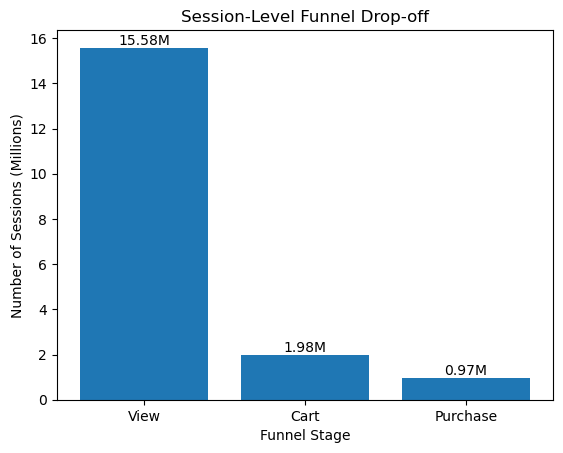

In [19]:
stages = ["View", "Cart", "Purchase"]
values = [view_sessions, cart_sessions, purchase_sessions]

# Convert to millions for readability
values_m = [v / 1_000_000 for v in values]

plt.figure()
bars = plt.bar(stages, values_m)

# Add labels
for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val / 1_000_000:.2f}M",
        ha='center',
        va='bottom'
    )

plt.title("Session-Level Funnel Drop-off")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Sessions (Millions)")

plt.show()

The bar chart highlights a steep drop-off from approximately 15.6M sessions at the view stage to around 2.0M at the cart stage, indicating that only about 12–13% of sessions progress to purchase intent. This confirms that the primary bottleneck in the funnel occurs immediately after product views.

In contrast, the transition from cart to purchase is relatively stronger, with nearly half of the cart sessions (~49%) converting into purchases. This suggests that once users demonstrate intent by adding items to the cart, they are significantly more likely to complete the transaction.

Overall, with only ~6% of sessions resulting in a purchase, improving the view-to-cart transition presents the largest opportunity to increase total conversions.

## Stage-wise Drop-off Analysis

In [20]:
view_to_cart_dropoff = 1 - view_to_cart_rate
cart_to_purchase_dropoff = 1 - cart_to_purchase_rate

view_to_cart_dropoff, cart_to_purchase_dropoff

(0.8726727805102508, 0.5109597390857616)

The drop-off analysis shows that approximately 87.3% of sessions do not progress from the view stage to the cart stage, indicating a significant loss of users at the initial stage of the funnel. This reinforces that the primary friction point lies in converting user interest into purchase intent.

Additionally, around 51.1% of sessions drop off between the cart and purchase stages. While this drop-off is lower compared to the earlier stage, it still represents a substantial loss, suggesting potential friction in the checkout process.

# User-Level Funnel Analysis

To complement the session-level analysis, user behavior is also examined at the user level. This helps determine whether users tend to convert within a single session or across multiple sessions over time.

## User-Level Aggregation

In [21]:
user_funnel = df.groupby("user_id")["event_type"].value_counts().unstack(fill_value=0)

## User-Level Aggregated Data Preview

In [22]:
user_funnel.head()

event_type,cart,purchase,view
user_id,,,
29515875,0,0,1
29990697,0,0,1
30493659,0,0,2
31198833,0,0,3
32836036,0,0,1


## User-Level Funnel Construction

In [23]:
user_funnel_binary = user_funnel.copy()

user_funnel_binary["view"] = (user_funnel_binary["view"] > 0).astype(int)
user_funnel_binary["cart"] = (user_funnel_binary["cart"] > 0).astype(int)
user_funnel_binary["purchase"] = (user_funnel_binary["purchase"] > 0).astype(int)

In [24]:
total_users = user_funnel_binary.shape[0]

view_users = user_funnel_binary["view"].sum()
cart_users = user_funnel_binary["cart"].sum()
purchase_users = user_funnel_binary["purchase"].sum()

view_to_cart_user_rate = cart_users / view_users
cart_to_purchase_user_rate = purchase_users / cart_users
view_to_purchase_user_rate = purchase_users / view_users

## User-Level Funnel Metrics Output

In [25]:
print("Total users:", total_users)
print("View users:", view_users)
print("Cart users:", cart_users)
print("Purchase users:", purchase_users)

print("View → Cart rate:", view_to_cart_user_rate)
print("Cart → Purchase rate:", cart_to_purchase_user_rate)
print("View → Purchase rate:", view_to_purchase_user_rate)

Total users: 4577231
View users: 4576955
Cart users: 923868
Purchase users: 500997
View → Cart rate: 0.20185210472901743
Cart → Purchase rate: 0.5422820143137331
View → Purchase rate: 0.10946076594591819


**Key Insights:**
- At the user level, approximately 20.2% of users progress from viewing to adding items to the cart, which is higher than the session-level conversion rate (12.7%). This indicates that users often require multiple sessions before reaching purchase intent.
- The cart-to-purchase conversion rate is stronger at the user level (54.2%), suggesting that once users show intent, they are likely to complete the purchase, even if not within the same session.
- The overall view-to-purchase conversion rate (10.9%) is notably higher than the session-level rate (6.2%), highlighting that analyzing behavior across sessions provides a more complete picture of user conversion.

## Session vs User Funnel Comparison

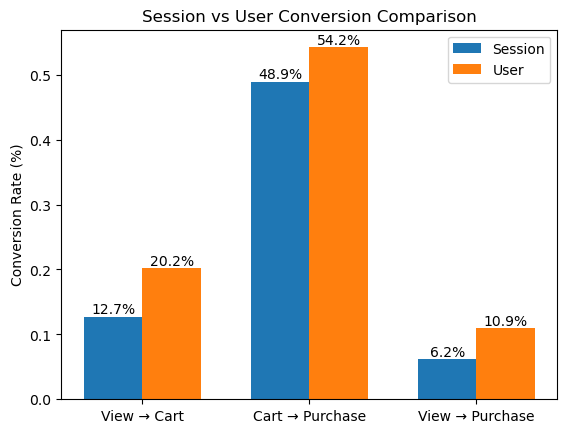

In [26]:
labels = ["View → Cart", "Cart → Purchase", "View → Purchase"]

session_rates = [
    view_to_cart_rate,
    cart_to_purchase_rate,
    view_to_purchase_rate
]

user_rates = [
    view_to_cart_user_rate,
    cart_to_purchase_user_rate,
    view_to_purchase_user_rate
]

x = np.arange(len(labels))
width = 0.35

plt.figure()

bars1 = plt.bar(x - width/2, session_rates, width, label='Session')
bars2 = plt.bar(x + width/2, user_rates, width, label='User')

# Add value labels (as percentages)
for i in range(len(labels)):
    plt.text(x[i] - width/2, session_rates[i], f"{session_rates[i]*100:.1f}%",
             ha='center', va='bottom')
    plt.text(x[i] + width/2, user_rates[i], f"{user_rates[i]*100:.1f}%",
             ha='center', va='bottom')

plt.xticks(x, labels)
plt.ylabel("Conversion Rate (%)")
plt.title("Session vs User Conversion Comparison")
plt.legend()

plt.show()

At the session level, 12.7% of sessions progress from view to cart, while at the user level this increases to 20.2%. This indicates that many users do not add items to the cart during their first visit but return later to complete this step.

The cart-to-purchase conversion rate is 48.9% at the session level and 54.2% at the user level, showing that once users add items to the cart, nearly half proceed to complete the purchase.

Overall, the view-to-purchase conversion increases from 6.2% at the session level to 10.9% at the user level, indicating that purchases often happen across multiple visits instead of a single session.

## User-Level Drop-off Analysis

In [28]:
# User-level drop-off calculation

view_to_cart_user_dropoff = 1 - view_to_cart_user_rate
cart_to_purchase_user_dropoff = 1 - cart_to_purchase_user_rate

print("View → Cart drop-off (User Level):", view_to_cart_user_dropoff)
print("Cart → Purchase drop-off (User Level):", cart_to_purchase_user_dropoff)

View → Cart drop-off (User Level): 0.7981478952709826
Cart → Purchase drop-off (User Level): 0.45771798568626687


At the user level, 79.8% of users do not progress from viewing to adding items to the cart, compared to a higher drop-off of 87.3% at the session level. This indicates that while many sessions fail to convert immediately, a portion of users return in later sessions and eventually add items to the cart. Similarly, the cart-to-purchase drop-off is 45.8% at the user level versus 51.1% at the session level, showing that users are more likely to complete purchases when their behavior is tracked across multiple sessions. Overall, the consistently lower drop-off rates at the user level suggest that conversions often occur over multiple visits rather than within a single session.